In [3]:
import warnings
warnings.filterwarnings('ignore')

import os
import json
import re
import numpy as np
from typing import TypedDict, Annotated, List, Literal

from dotenv import load_dotenv
load_dotenv()

from pydantic import BaseModel
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_huggingface import HuggingFacePipeline, ChatHuggingFace
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import torch
import time


In [5]:
# Here I'm Going to Define my State for Agent

class AgentState(TypedDict):
    Query: Annotated[List[BaseMessage], add_messages] # Here I Use add messages beacuse i want to ensure every message should store
    Response: Annotated[List[BaseMessage], add_messages]
    logs: str
    Answerable: dict
    retrieved_passages: list
    Retries: int
    Confidence: float
    require_human: bool
    reason: str


In [6]:
#Defining for our structure output schemas

class UserQuery(BaseModel):
    answerable: bool
    Requires_clarification: bool
    Requires_escalation: bool
    Out_of_scope: bool


    
User_Query_parser = PydanticOutputParser(pydantic_object=UserQuery)


In [7]:
#Defining model and also Downloading it locally from huggingface lib

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"  # Here we use 2.5B parameter model ,we can switch according to oue system needs
print(f"Loading local LLM: {MODEL_NAME} ...")
t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_lm = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float32)
pipe = pipeline(
    "text-generation",
    model=model_lm,
    tokenizer=tokenizer,
    max_new_tokens=512,
    return_full_text=False,
)
llm = HuggingFacePipeline(pipeline=pipe)
model = ChatHuggingFace(llm=llm)
print(f"LLM loaded in {time.time() - t0:.2f}s")


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6486.98it/s]


Loading local LLM: Qwen/Qwen2.5-0.5B-Instruct ...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 290/290 [00:03<00:00, 95.23it/s] 
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


LLM loaded in 9.25s


In [14]:
#Now.Chunking and EMbedding our Folder knowledge base

def load_markdown_docs(folder_path: str) -> list[dict]:
    docs = []
    for fname in os.listdir(folder_path):
        if not fname.lower().endswith(".md"):
            continue
        path = os.path.join(folder_path, fname)
        with open(path, "r", encoding="utf-8") as f:
            text = f.read()
        docs.append({"document": fname, "text": text})
    return docs


def chunk_markdown(text: str, min_chunk_len: int = 100) -> list[str]:
    raw_chunks = [c.strip() for c in text.split("\n\n") if c.strip()]
    merged = []
    buffer = ""
    for chunk in raw_chunks:
        buffer = (buffer + "\n\n" + chunk).strip() if buffer else chunk
        if len(buffer) >= min_chunk_len:
            merged.append(buffer)
            buffer = ""
    if buffer:
        merged.append(buffer)
    return merged


def build_corpus_from_markdown(folder_path: str) -> list[dict]:
    corpus = []
    for doc in load_markdown_docs(folder_path):
        for i, chunk in enumerate(chunk_markdown(doc["text"])):
            corpus.append({
                "document": doc["document"],
                "passage_id": f"chunk_{i}",
                "text": chunk,
            })
    return corpus

In [15]:
FOLDER = "./knowledge_base"  # <-- put your .md files here
corpus = build_corpus_from_markdown(folder_path=FOLDER)
corpus_texts = [c["text"] for c in corpus]
print(f"Built corpus with {len(corpus)} chunks from markdown files")


Built corpus with 69 chunks from markdown files


In [16]:
corpus_embeddings = embedding_model.encode(corpus_texts, normalize_embeddings=True) if corpus_texts else np.array([])


#Retrive the Top k chunks which is equaly likely 
def retrieve(query: str, top_k: int = 3) -> list[dict]:
    if len(corpus) == 0:
        return []
    query_embedding = embedding_model.encode([query], normalize_embeddings=True)
    scores = cosine_similarity(query_embedding, corpus_embeddings)[0]
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [
        {
            "document": corpus[idx]["document"],
            "passage_id": corpus[idx]["passage_id"],
            "text": corpus[idx]["text"],
            "score": float(scores[idx]),
        }
        for idx in top_indices
    ]


In [17]:
#Using prompt template to feen in llm for consistent output


user_query_Prompt = PromptTemplate(
    template="""
{eval_instruction}

{format_instruction}

submission : {user_input}""",
    input_variables=['user_input', 'eval_instruction'],
    partial_variables={'format_instruction': User_Query_parser.get_format_instructions()}
)
Query_chain = user_query_Prompt | model | User_Query_parser

generation_prompt = PromptTemplate(
    template="""You are a support assistant. Answer the question using ONLY the evidence below.
Do not use any outside knowledge. Do not invent steps or instructions that are not in the evidence.
If the evidence does not fully answer the question, say so honestly rather than guessing.
Cite the source document name for every claim.

Evidence:
{context}

Question: {question}

Respond ONLY in this exact JSON format, nothing else:
{{"answer": "your answer here", "sources": [{{"document": "filename", "passage": "passage_id"}}], "confidence": 0.0}}""",
    input_variables=["context", "question"],
)
generation_chain = generation_prompt | model

revise_prompt = PromptTemplate(
    template="""Fix this: your last answer failed because '{failure_reason}'.
Answer again using ONLY this evidence: {context}
Question: {question}
Return JSON with fields: answer, sources, confidence.""",
    input_variables=["failure_reason", "context", "question"],
)
revise_chain = revise_prompt | model

In [18]:
# User Query 

def User_Query(state: AgentState) -> AgentState:
    output = Query_chain.invoke({
        "user_input": state['Query'],
        "eval_instruction": """On given user input, return the following output:
        answerable
        Requires_clarification
        Requires_escalation
        Out_of_scope"""
    })

    result = output.model_dump()
    update = {
        "Answerable": result,
        "logs": state.get("logs", "") + f"\n[User_Query] triage={result}",
    }

    # write a final response here if not answerable, so END never gets an empty Response
    if not result.get("answerable"):
        if result.get("Requires_clarification"):
            answer, requires_human, reason = (
                "Could you clarify your request? I need more specific details to help.",
                False, "requires clarification"
            )
        elif result.get("Requires_escalation"):
            answer, requires_human, reason = (
                "This request needs to be handled by a human agent.",
                True, "requires escalation"
            )
        else:
            answer, requires_human, reason = (
                "This request is outside what I can help with here.",
                False, "out of scope"
            )

        msg = json.dumps({
            "answer": answer, "sources": [], "confidence": 0.0,
            "requires_human": requires_human, "reason": reason,
        })
        update["Response"] = [AIMessage(content=msg)]
        update["require_human"] = requires_human

    return update


In [27]:
#Triage will be Four types hete

def check_triage_classification(state: AgentState) -> str:
    triage_result = state.get("Answerable", {})
    if triage_result.get("answerable"):
        return "answerable"
    elif triage_result.get("Requires_clarification"):
        return "Requires_clarification"
    elif triage_result.get("Requires_escalation"):
        return "Requires_escalation"
    else:
        return "out_of_scope"

In [19]:
 #Retrival node

def Retrieval(state: AgentState) -> AgentState:
    query_text = state["Query"][-1].content
    results = retrieve(query_text, top_k=3)# calling the fucntion 

    log_line = (
        f"[Retrieval] top_score={results[0]['score']:.3f}, chunks_retrieved={len(results)}"
        if results else "[Retrieval] no chunks found"
    )

    return {
        "retrieved_passages": results,
        "logs": state.get("logs", "") + "\n" + log_line,
    }

In [20]:
#Generate the Response if LLm can  Answer them
def Generation(state: AgentState) -> AgentState:
    query_text = state["Query"][-1].content
    passages = state.get("retrieved_passages", [])

    if not passages:
        log_line = "[Generation] skipped — no retrieved passages"
        return {
            "Response": [AIMessage(content='{"answer": "", "sources": [], "confidence": 0.0}')],
            "logs": state.get("logs", "") + "\n" + log_line,
        }

    context = "\n\n".join(
        f"[Source: {p['document']} | {p['passage_id']}]\n{p['text']}" for p in passages
    )

    result = generation_chain.invoke({"context": context, "question": query_text})

    log_line = f"[Generation] generated {len(result.content)} chars from {len(passages)} passages"

    return {
        "Response": [AIMessage(content=result.content)],
        "logs": state.get("logs", "") + "\n" + log_line,
    }


In [21]:
# Verofication if it is pass or fail
def Verification(state: AgentState) -> AgentState:
    text = state["Response"][-1].content
    passages = state.get("retrieved_passages", [])

    match = re.search(r"\{.*\}", text, re.DOTALL)
    try:
        parsed = json.loads(match.group()) if match else None
    except Exception:
        parsed = None

    passed = True
    reason = ""

    if parsed is None or "answer" not in parsed or "sources" not in parsed:
        passed = False
        reason = "bad JSON format"
    elif not parsed.get("sources"):
        passed = False
        reason = "no sources cited"
    elif not passages:
        passed = False
        reason = "no evidence retrieved"
    elif not parsed.get("answer", "").strip():
        passed = False
        reason = "empty answer"

    confidence = parsed.get("confidence", 0.0) if parsed else 0.0

    return {
        "reason": "" if passed else reason,
        "Confidence": confidence,
        "logs": state.get("logs", "") + f"\n[Verification] passed={passed} reason={reason}",
    }



In [22]:
#check accoding to verification
def check_verification(state: AgentState) -> str:
    if state.get("reason", "") == "":
        return "end"
    if state.get("Retries", 0) >= 1:
        return "safe_fail"
    return "revise"

In [24]:
# revise 1 Retry if more than 1 retry then safe fail it
def Revise(state: AgentState) -> AgentState:
    query = state["Query"][-1].content
    passages = state.get("retrieved_passages", [])
    context = "\n".join(p["text"] for p in passages)

    result = revise_chain.invoke({
        "failure_reason": state["reason"],
        "context": context,
        "question": query,
    })

    return {
        "Response": [AIMessage(content=result.content)],
        "Retries": state.get("Retries", 0) + 1,
        "logs": state.get("logs", "") + "\n[Revise] retrying",
    }


In [25]:

def SafeFail(state: AgentState) -> AgentState:
    fallback = json.dumps({
        "answer": "Not confident enough to answer — flagged for human review.",
        "sources": [],
        "confidence": 0.0,
        "requires_human": True,
        "reason": state.get("reason", ""),
    })
    return {
        "Response": [AIMessage(content=fallback)],
        "require_human": True,
        "logs": state.get("logs", "") + "\n[SafeFail] returning safe fallback",
    }

In [28]:
graph = StateGraph(AgentState)

graph.add_node("User_Query", User_Query)
graph.add_node("Retrival", Retrieval)
graph.add_node("Generate_Response", Generation)
graph.add_node("Verification", Verification)
graph.add_node("Revise", Revise)
graph.add_node("SafeFail", SafeFail)

graph.add_edge(START, "User_Query")

graph.add_conditional_edges(
    "User_Query",
    check_triage_classification,
    {
        "answerable": "Retrival",
        "Requires_clarification": END,
        "Requires_escalation": END,
        "out_of_scope": END,
    }
)

graph.add_edge("Retrival", "Generate_Response")
graph.add_edge("Generate_Response", "Verification")

graph.add_conditional_edges(
    "Verification",
    check_verification,
    {
        "revise": "Revise",
        "safe_fail": "SafeFail",
        "end": END,
    }
)

graph.add_edge("Revise", "Verification")
graph.add_edge("SafeFail", END)

app = graph.compile()

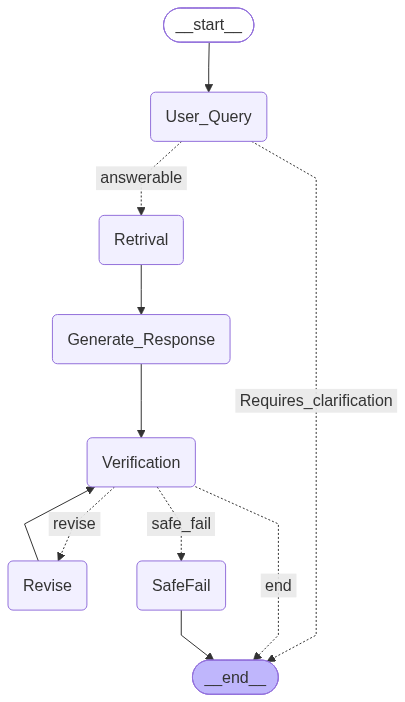

In [29]:
from IPython.display import Image

Image(app.get_graph().draw_mermaid_png())

In [33]:
# Lets check our System noww


initial_state = {
        "Query": [HumanMessage("Our daily dashboard exports stopped appearing at the expected time after an Admin changed the workspace timezone yesterday. The schedule still looks active. What should we check, and can the missed export be recovered?")],
        "Response": [],
        "logs": "",
        "Answerable": {},
        "retrieved_passages": [],
        "Retries": 0,
        "Confidence": 0.0,
        "require_human": False,
        "reason": "",
    }

final_state = app.invoke(initial_state)

print("\n--- FINAL RESPONSE ---")
print(final_state["Response"][-1].content)
print("\n--- LOGS ---")
print(final_state["logs"])

[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- FINAL RESPONSE ---
{"answer": "Could you clarify your request? I need more specific details to help.", "sources": [], "confidence": 0.0, "requires_human": false, "reason": "requires clarification"}

--- LOGS ---

[User_Query] triage={'answerable': False, 'Requires_clarification': True, 'Requires_escalation': False, 'Out_of_scope': False}
